# Phase 2 — Exploratory Data Analysis & Visualisation

## Purpose

Before preprocessing or training any model, this notebook answers the essential questions about the data:

- How severe is the class imbalance — and what does it mean for model evaluation?
- How long are sentences, and does length vary by interaction type?
- Which drugs and drug pairs appear most often?
- What entity types are involved, and does type predict interaction?
- Which keywords signal each interaction type — justifying the rule-based baseline?
- Are there data quality issues (cross-split leakage, self-pairs, offset errors)?
- Is the BioBERT token limit appropriate for this corpus?

Every finding here directly informs a decision in Phase 3 (preprocessing), Phase 4 (features/models), or Phase 5 (BioBERT).

**Pipeline position:**
```
Phase 1: Parse XML  →  [Phase 2: EDA]  →  Phase 3: Preprocess  →  Phase 4: Features+Models  →  Phase 5: BioBERT
```

**Input:** `train.csv`, `test.csv` from Phase 1  
**Outputs:** `outputs/figures/` — all plots | `outputs/eda_summary.csv` — aggregated statistics

## 1. Imports & Setup

In [ ]:
import os
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')

# Output directories
FIG_DIR = Path('outputs/figures')
DAT_DIR = Path('outputs/data')
FIG_DIR.mkdir(parents=True, exist_ok=True)
DAT_DIR.mkdir(parents=True, exist_ok=True)

# Consistent colour palette
# One colour per interaction type — used across every plot for instant recognition
LABEL_COLOURS = {
    'false': '#888780',
    'effect': '#378ADD',
    'mechanism': '#7F77DD',
    'advise': '#EF9F27',
    'int': '#D85A30',
}
LABEL_ORDER = ['false', 'effect', 'mechanism', 'advise', 'int']

# Global plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100,
})

def save_fig(name):
    """Save figure at report quality and display it."""
    path = FIG_DIR / f'{name}.png'
    plt.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved -> {path}')

print('Setup complete.')
print(f'Figures -> {FIG_DIR.resolve()}')
print(f'Data -> {DAT_DIR.resolve()}')

Setup complete.
  Figures -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/notebooks/exploratory_data_analysis/outputs/figures
  Data    -> /Users/carinadesouza/Documents/Projects/Python/Drug Drug Interaction NLP project/notebooks/exploratory_data_analysis/outputs/data


## 2. Load Data

Load train and test CSVs and create a combined dataframe for full-corpus analysis.

**Derived columns created here** (used throughout the notebook):
- `sentence_length` — word count of each sentence
- `type_combo` — combined entity type string (e.g. `drug + group`)
- `split` — which CSV the row came from (`train` / `test`)

In [ ]:
# Paths — adjust if your folder structure differs
TRAIN_PATH = '../../data/processed/train.csv'
TEST_PATH  = '../../data/processed/test.csv'
#

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Tag each split before combining
train_df['split'] = 'train'
test_df['split'] = 'test'
df = pd.concat([train_df, test_df], ignore_index=True)

# Derived columns
df['sentence_length'] = df['sentence_text'].str.split().str.len()
df['type_combo'] = df['drug1_type'] + ' + ' + df['drug2_type']

print(f'Train : {len(train_df):,} rows')
print(f'Test : {len(test_df):,} rows')
print(f'Total : {len(df):,} rows')
print(f'Columns: {list(df.columns)}')
print(f'\nddi dtype: {df["ddi"].dtype}  — must be bool')
print(f'ddi True count: {df["ddi"].sum():,}  ({df["ddi"].mean()*100:.1f}% of pairs have interaction)')

Train : 27,792 rows
Test  : 6,657 rows
Total : 34,449 rows
Columns: ['sentence_id', 'sentence_text', 'drug1_id', 'drug1_text', 'drug1_type', 'drug2_id', 'drug2_text', 'drug2_type', 'ddi', 'interaction_type', 'corpus_source', 'offset_valid', 'source_file', 'split', 'sentence_length', 'type_combo']

ddi dtype: bool  — must be bool
ddi True count: 5,000  (14.5% of pairs have interaction)


## 3. Class Distribution

The single most important EDA finding. The `false` class (no interaction) makes up **85.5%** of all pairs — a 125× imbalance over the rarest class (`int`).

**Why this matters:**
- Accuracy is meaningless — a model predicting `false` every time would be 85.5% accurate but clinically useless
- We use **Macro F1** as the metric, which averages F1 equally across all 5 classes
- Both Random Forest and SVM use `class_weight='balanced'` to correct for this

> **Note on visualisation:** A pie chart is avoided here because the `int` class (0.8%) becomes an invisible sliver. A bar chart with log scale on the right clearly shows both the dominant class and the minority classes simultaneously.

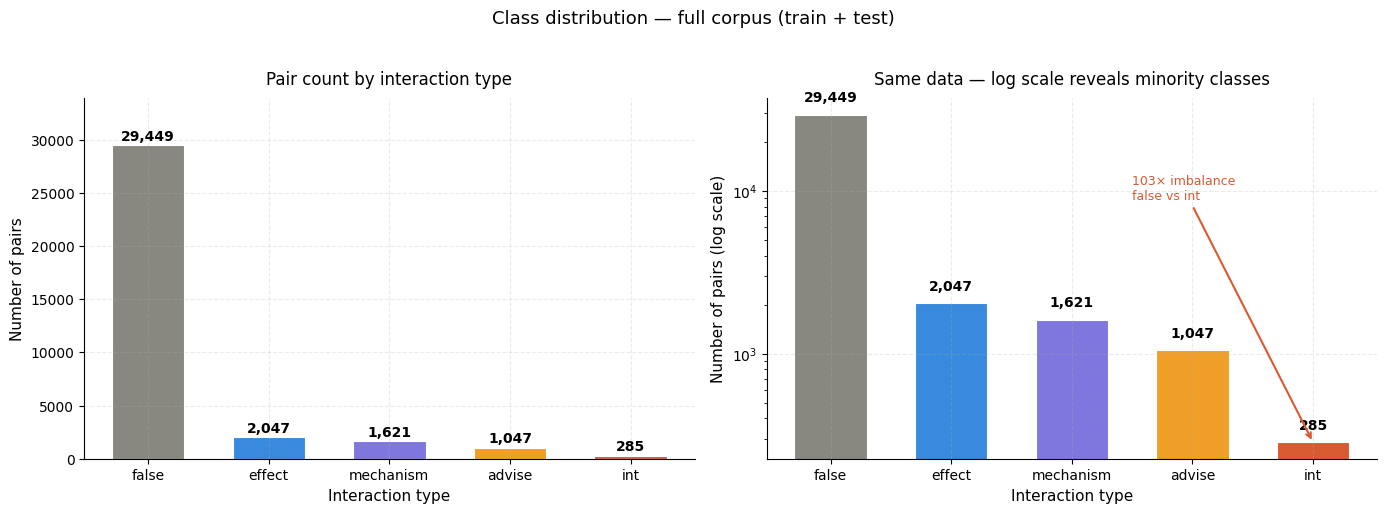

  Saved -> outputs/figures/01_class_distribution.png
Class distribution:
  false        29,449  (85.5%)
  effect        2,047  (5.9%)
  mechanism     1,621  (4.7%)
  advise        1,047  (3.0%)
  int             285  (0.8%)

Imbalance ratio (false / int): 103.3×
=> Use Macro F1, not accuracy. Use class_weight=balanced in models.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['interaction_type'].value_counts().reindex(LABEL_ORDER)
colours = [LABEL_COLOURS[l] for l in LABEL_ORDER]

# Left: raw counts
bars = axes[0].bar(
    counts.index, counts.values,
    color=colours, width=0.6,
    edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 180,
        f'{val:,}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
axes[0].set_title('Pair count by interaction type', pad=10)
axes[0].set_xlabel('Interaction type')
axes[0].set_ylabel('Number of pairs')
axes[0].set_ylim(0, counts.max() * 1.15)

# Right: log-scale to show minority classes clearly
axes[1].bar(counts.index, counts.values, color=colours, width=0.6,
            edgecolor='white', linewidth=0.8)
axes[1].set_yscale('log')
axes[1].set_title('Same data — log scale reveals minority classes', pad=10)
axes[1].set_xlabel('Interaction type')
axes[1].set_ylabel('Number of pairs (log scale)')
for bar, val in zip(axes[1].patches, counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.15,
        f'{val:,}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Imbalance annotation
ratio = counts['false'] / counts['int']
axes[1].annotate(
    f'{ratio:.0f}× imbalance\nfalse vs int',
    xy=(4, counts['int']), xytext=(2.5, counts['false'] * 0.3),
    fontsize=9, color='#D85A30',
    arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1.5)
)

plt.suptitle('Class distribution — full corpus (train + test)', fontsize=13, y=1.02)
plt.tight_layout()
save_fig('01_class_distribution')

print('Class distribution:')
for label in LABEL_ORDER:
    pct = counts[label] / counts.sum() * 100
    print(f'  {label:<12} {counts[label]:6,}  ({pct:.1f}%)')
print(f'\nImbalance ratio (false / int): {ratio:.1f}×')
print('=> Use Macro F1, not accuracy. Use class_weight=balanced in models.')

## 4. Train / Test Split Consistency

Checks that the class distribution is similar in both splits. A large difference would indicate the split is not representative — which could make test F1 misleadingly high or low.

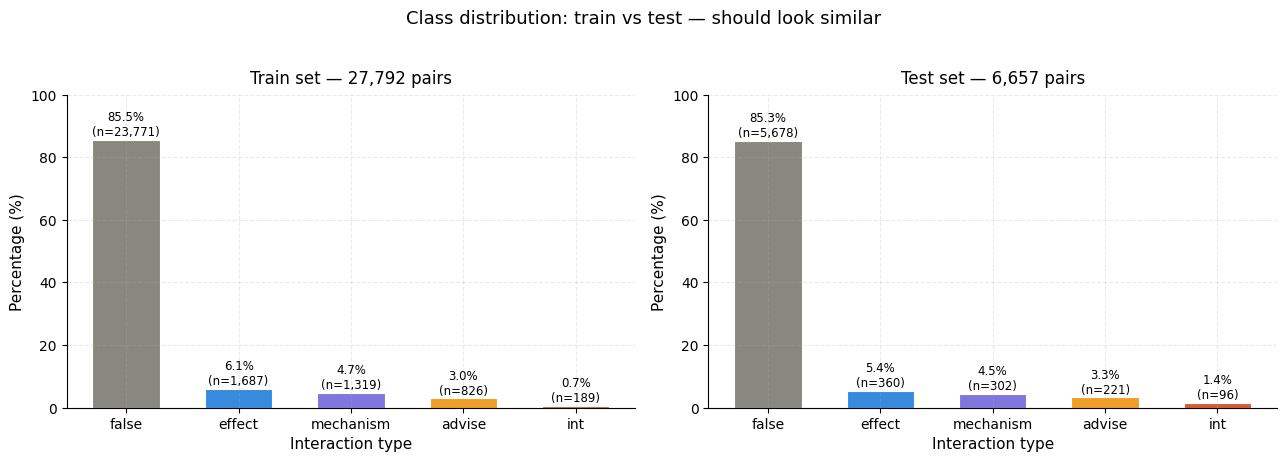

  Saved -> outputs/figures/02_train_test_split.png
Distributions should match closely — large differences = sampling bias.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (split_name, sdf) in zip(axes, [('Train', train_df), ('Test', test_df)]):
    counts = sdf['interaction_type'].value_counts().reindex(LABEL_ORDER)
    pcts   = counts / counts.sum() * 100
    colours = [LABEL_COLOURS[l] for l in LABEL_ORDER]

    bars = ax.bar(counts.index, pcts.values, color=colours,
                  width=0.6, edgecolor='white', linewidth=0.8)

    for bar, pct, cnt in zip(bars, pcts.values, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f'{pct:.1f}%\n(n={cnt:,})',
                ha='center', va='bottom', fontsize=8.5)

    ax.set_title(f'{split_name} set — {len(sdf):,} pairs', pad=8)
    ax.set_xlabel('Interaction type')
    ax.set_ylabel('Percentage (%)')
    ax.set_ylim(0, 100)

plt.suptitle('Class distribution: train vs test — should look similar', fontsize=13, y=1.02)
plt.tight_layout()
save_fig('02_train_test_split')
print('Distributions should match closely — large differences = sampling bias.')

## 5. Sentence Length Analysis

Sentence length affects model performance in two ways:
1. Very short sentences may lack enough context to identify interaction type
2. Sentences exceeding BioBERT's 512-token limit are silently truncated (analysed in Section 11)

**Key finding:** `false` sentences average **36 words** vs ~27 words for true interactions. This makes sense — sentences listing many drugs without specifying interactions tend to be long enumerations.

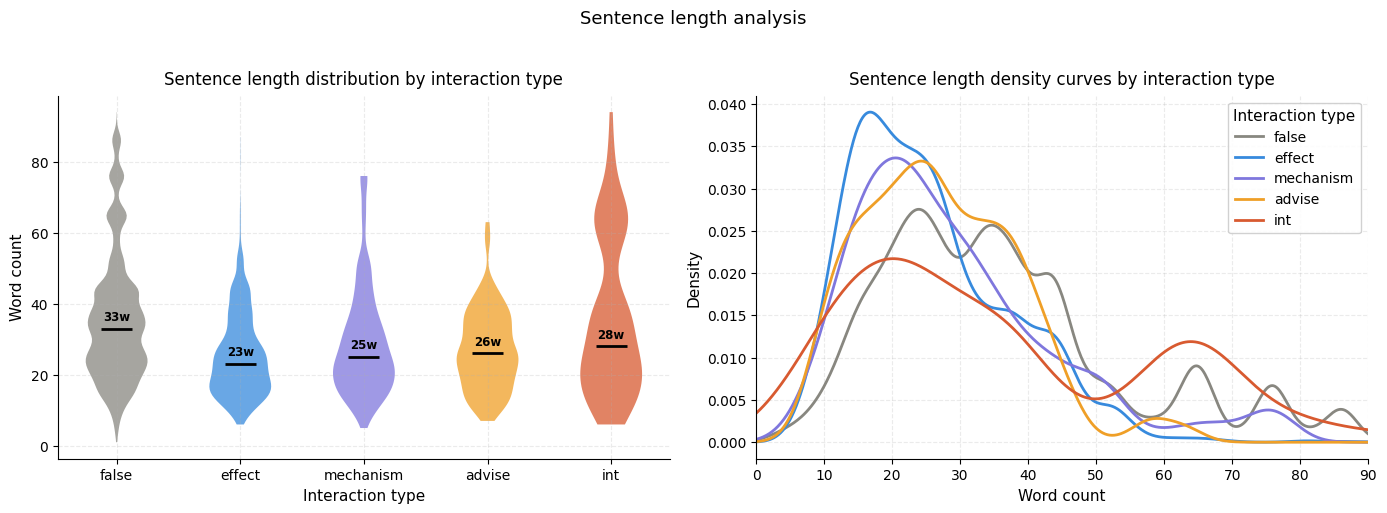

  Saved -> outputs/figures/03_sentence_length.png
Mean sentence length per class:
  false        36.0 words
  effect       25.5 words
  mechanism    29.1 words
  advise       27.0 words
  int          35.9 words

Sentences > 100 words: 0 rows
=> sentence_length is a weak but real feature. Justified as handcrafted feature in Phase 4.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_by_label = [
    df[df['interaction_type'] == l]['sentence_length'].values
    for l in LABEL_ORDER
]

# Left: violin plot (more informative than boxplot — shows full distribution)
parts = axes[0].violinplot(
    data_by_label, positions=range(len(LABEL_ORDER)),
    showmedians=True, showextrema=False
)
for i, (pc, label) in enumerate(zip(parts['bodies'], LABEL_ORDER)):
    pc.set_facecolor(LABEL_COLOURS[label])
    pc.set_alpha(0.75)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

axes[0].set_xticks(range(len(LABEL_ORDER)))
axes[0].set_xticklabels(LABEL_ORDER)
axes[0].set_title('Sentence length distribution by interaction type', pad=8)
axes[0].set_xlabel('Interaction type')
axes[0].set_ylabel('Word count')

# Annotate medians
for i, label in enumerate(LABEL_ORDER):
    median = np.median(data_by_label[i])
    axes[0].text(i, median + 1.5, f'{median:.0f}w',
                 ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Right: overlapping density curves
for label in LABEL_ORDER:
    subset = df[df['interaction_type'] == label]['sentence_length']
    subset.plot.kde(ax=axes[1], label=label,
                    color=LABEL_COLOURS[label], linewidth=2)

axes[1].set_xlim(0, 90)
axes[1].set_title('Sentence length density curves by interaction type', pad=8)
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Density')
axes[1].legend(title='Interaction type', framealpha=0.9)

plt.suptitle('Sentence length analysis', fontsize=13, y=1.02)
plt.tight_layout()
save_fig('03_sentence_length')

print('Mean sentence length per class:')
means = df.groupby('interaction_type')['sentence_length'].mean().reindex(LABEL_ORDER).round(1)
for label, mean in means.items():
    print(f'{label:<12} {mean} words')
print(f'\nSentences > 100 words: {(df["sentence_length"]>100).sum()} rows')
print('=> sentence_length is a weak but real feature. Justified as handcrafted feature in Phase 4.')

## 6. Drug Frequency Analysis

Which drugs appear most often — and which appear most often in *positive* interactions?

**Why this matters for your model:**
- High-frequency drugs (warfarin, insulin) will dominate training — the model may overfit to their specific interaction patterns
- Low-frequency drugs get fewer training examples — the model generalises poorly to them
- Comparing overall frequency vs interaction-only frequency reveals which drugs are genuinely high-risk

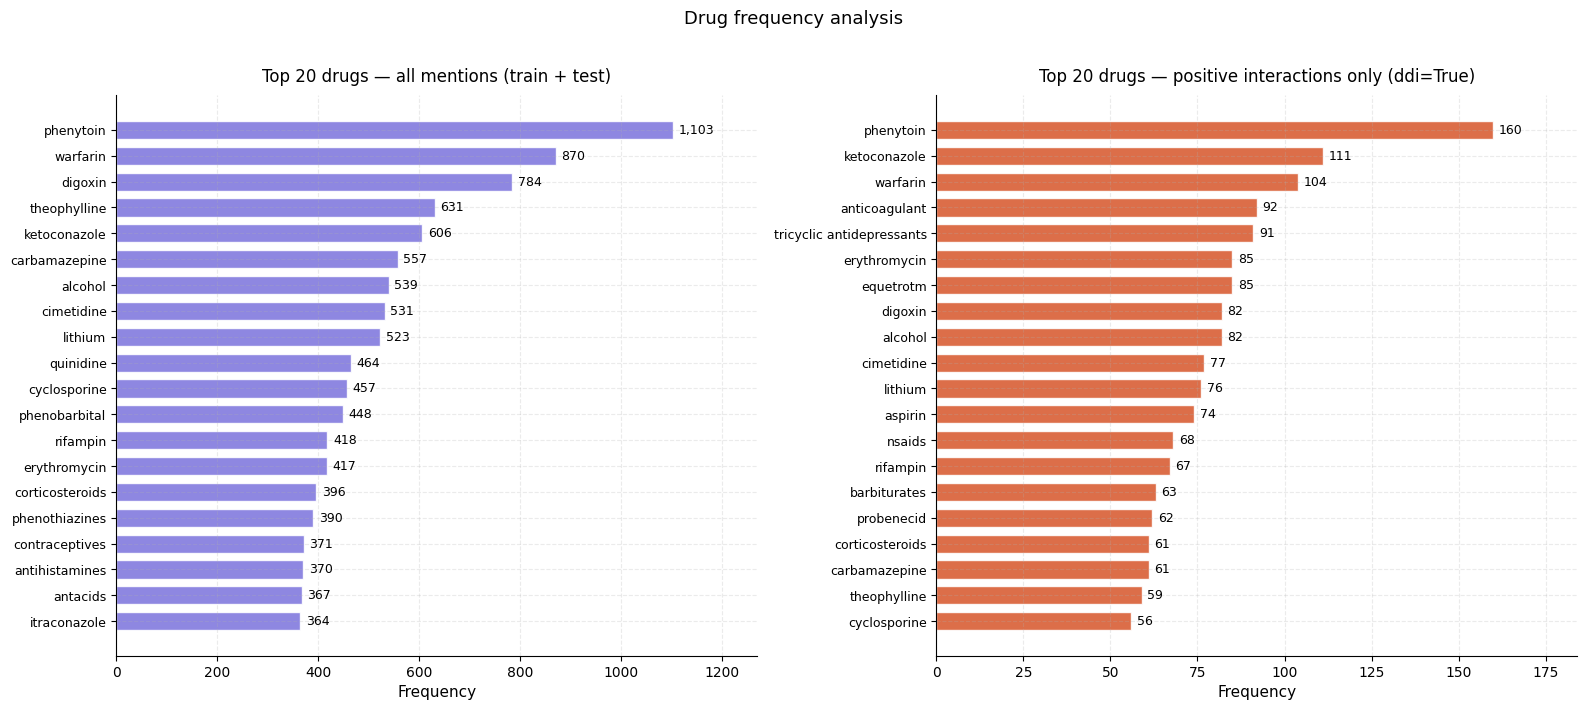

  Saved -> outputs/figures/04_drug_frequency.png
Total unique drug names in corpus : 2,731
Total unique drugs in interactions: 1,774

Top 5 overall: ['phenytoin', 'warfarin', 'digoxin', 'theophylline', 'ketoconazole']
Top 5 in interactions: ['phenytoin', 'ketoconazole', 'warfarin', 'anticoagulant', 'tricyclic antidepressants']


In [ ]:
all_drugs = pd.concat([df['drug1_text'], df['drug2_text']]).str.lower().str.strip()
drug_freq = all_drugs.value_counts()

pos_df = df[df['ddi'] == True]
pos_drugs = pd.concat([pos_df['drug1_text'], pos_df['drug2_text']]).str.lower().str.strip()
pos_freq  = pos_drugs.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, freq, title, colour in zip(
    axes,
    [drug_freq.head(20), pos_freq.head(20)],
    ['Top 20 drugs — all mentions (train + test)',
     'Top 20 drugs — positive interactions only (ddi=True)'],
    ['#7F77DD', '#D85A30']
):
    ax.barh(freq.index[::-1], freq.values[::-1],
            color=colour, edgecolor='white', alpha=0.88, height=0.7)
    for i, (name, val) in enumerate(zip(freq.index[::-1], freq.values[::-1])):
        ax.text(val + freq.values.max() * 0.01, i,
                f'{val:,}', va='center', fontsize=9)
    ax.set_title(title, pad=10)
    ax.set_xlabel('Frequency')
    ax.margins(x=0.15)
    ax.yaxis.set_tick_params(labelsize=9)

plt.suptitle('Drug frequency analysis', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('04_drug_frequency')

print(f'Total unique drug names in corpus : {drug_freq.shape[0]:,}')
print(f'Total unique drugs in interactions: {pos_freq.shape[0]:,}')
print(f'\nTop 5 overall: {list(drug_freq.head(5).index)}')
print(f'Top 5 in interactions: {list(pos_freq.head(5).index)}')

## 7. Interaction Type Breakdown for Top Drugs

For the top 10 most-mentioned drugs, what fraction of their pairs belong to each interaction type? This reveals whether certain drugs are associated with specific interaction categories — useful context for Phase 6 demo selection.

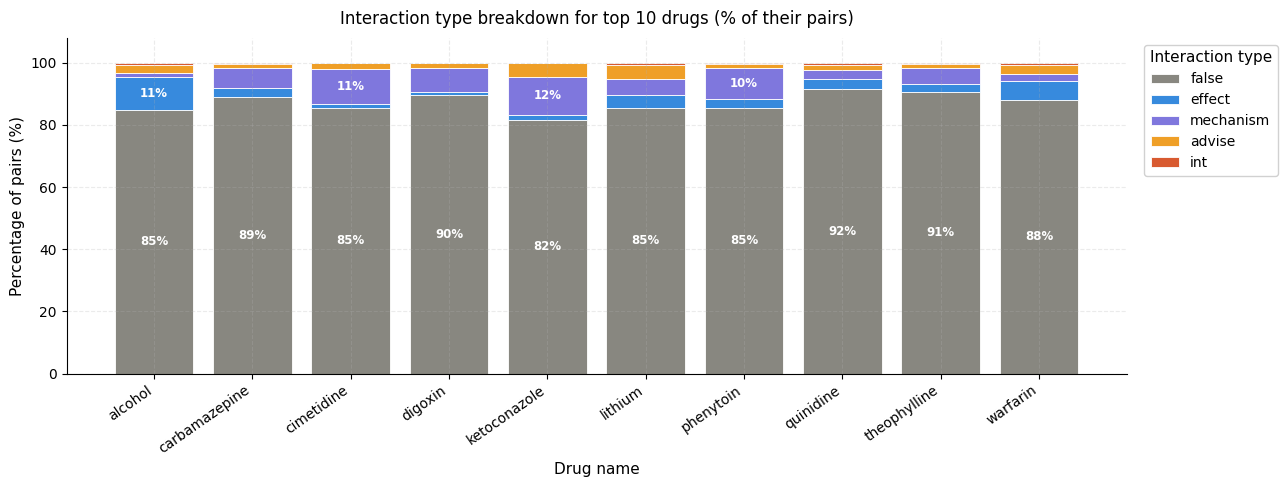

  Saved -> outputs/figures/05_drug_interaction_breakdown.png


In [ ]:
top10_drugs = drug_freq.head(10).index.tolist()

stacked = pd.concat([
    df[['drug1_text', 'interaction_type']].rename(columns={'drug1_text': 'drug'}),
    df[['drug2_text', 'interaction_type']].rename(columns={'drug2_text': 'drug'}),
])
stacked['drug'] = stacked['drug'].str.lower().str.strip()
stacked = stacked[stacked['drug'].isin(top10_drugs)]

pivot = stacked.groupby(['drug', 'interaction_type']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=LABEL_ORDER, fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(pivot_pct))

for label in LABEL_ORDER:
    vals = pivot_pct[label].values
    bars = ax.bar(pivot_pct.index, vals, bottom=bottom,
                  label=label, color=LABEL_COLOURS[label],
                  edgecolor='white', linewidth=0.6)
    # Label segments > 8% only (avoids clutter)
    for bar, val in zip(bars, vals):
        if val > 8:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.0f}%',
                ha='center', va='center', fontsize=8.5,
                color='white', fontweight='bold'
            )
    bottom += vals

ax.set_title('Interaction type breakdown for top 10 drugs (% of their pairs)', pad=10)
ax.set_xlabel('Drug name')
ax.set_ylabel('Percentage of pairs (%)')
ax.set_ylim(0, 108)
ax.legend(title='Interaction type', bbox_to_anchor=(1.01, 1),
          loc='upper left', framealpha=0.9)
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.tight_layout()
save_fig('05_drug_interaction_breakdown')

## 8. Drug Entity Type Analysis

Each drug entity is labelled as one of four types:
- `drug` — specific generic drug (e.g. warfarin)
- `brand` — trade name (e.g. Tylenol)
- `group` — drug class (e.g. NSAIDs, beta-blockers)
- `drug_n` — unapproved or experimental compound

**Why this matters:** Group + group and group + drug interactions are qualitatively different from specific drug pairs. Entity type is used as a handcrafted feature in Phase 4.

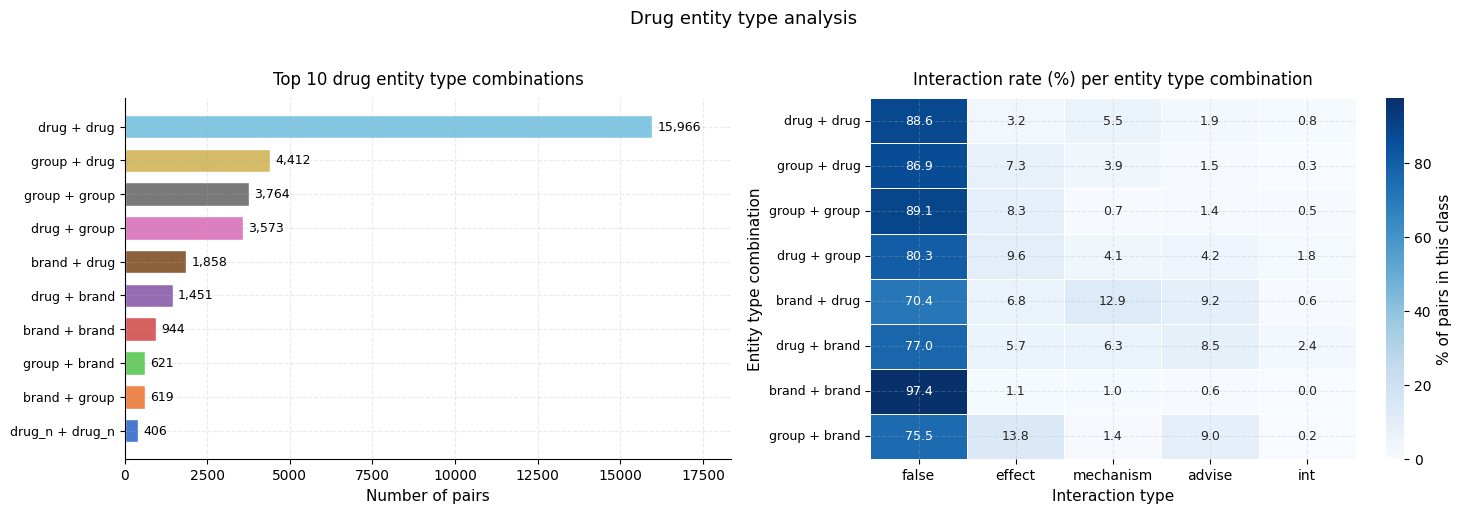

  Saved -> outputs/figures/06_drug_entity_types.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: top entity type combinations
combo_counts = df['type_combo'].value_counts().head(10)
colours_bar  = sns.color_palette('muted', len(combo_counts))

axes[0].barh(combo_counts.index[::-1], combo_counts.values[::-1],
             color=colours_bar, edgecolor='white', height=0.7)
for i, val in enumerate(combo_counts.values[::-1]):
    axes[0].text(val + combo_counts.values.max() * 0.01, i,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_title('Top 10 drug entity type combinations', pad=10)
axes[0].set_xlabel('Number of pairs')
axes[0].margins(x=0.15)
axes[0].yaxis.set_tick_params(labelsize=9)

# Right: interaction rate heatmap per type combo
top8 = df['type_combo'].value_counts().head(8).index
combo_label = pd.crosstab(df['type_combo'], df['interaction_type'])
combo_label = combo_label.reindex(index=top8, columns=LABEL_ORDER, fill_value=0)

# Normalise to interaction RATE (%) per combo
combo_rate = combo_label.div(combo_label.sum(axis=1), axis=0) * 100

sns.heatmap(
    combo_rate, ax=axes[1],
    annot=True, fmt='.1f',
    cmap='Blues', linewidths=0.5,
    cbar_kws={'label': '% of pairs in this class'},
    annot_kws={'size': 9}
)
axes[1].set_title('Interaction rate (%) per entity type combination', pad=10)
axes[1].set_xlabel('Interaction type')
axes[1].set_ylabel('Entity type combination')
axes[1].tick_params(axis='y', labelsize=9)

plt.suptitle('Drug entity type analysis', fontsize=13, y=1.02)
plt.tight_layout()
save_fig('06_drug_entity_types')

## 9. Pairs Per Sentence Distribution

One sentence with N drugs generates N×(N-1)/2 pairs. A sentence mentioning 5 drugs generates 10 pairs — most of which will be `false` (the drugs co-occur but don't interact). This is the **primary driver of class imbalance** and explains why the dataset has 85.5% false pairs even though the underlying sentences often do describe a real interaction.

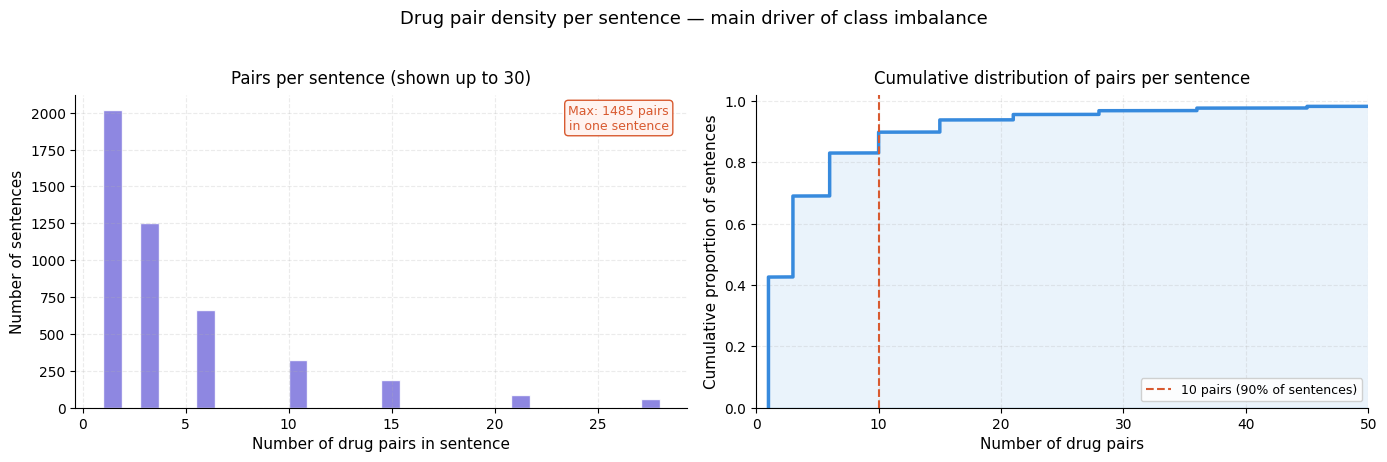

  Saved -> outputs/figures/07_pairs_per_sentence.png
Sentences with 1 pair    : 2,021 (42.6%)
Sentences with 2–5 pairs : 1,253
Sentences with >10 pairs : 486 (10.2%)
Max pairs in one sentence: 1485


In [ ]:
pairs_per = df.groupby('sentence_id').size().reset_index(name='pair_count')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: histogram (capped at 30 for readability)
cap = pairs_per[pairs_per['pair_count'] <= 30]['pair_count']
axes[0].hist(cap, bins=30, color='#7F77DD', edgecolor='white', alpha=0.88)
axes[0].set_title('Pairs per sentence (shown up to 30)', pad=8)
axes[0].set_xlabel('Number of drug pairs in sentence')
axes[0].set_ylabel('Number of sentences')
axes[0].text(0.97, 0.97,
             f'Max: {pairs_per["pair_count"].max()} pairs\nin one sentence',
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=9, color='#D85A30',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3F0', edgecolor='#D85A30'))

# Right: cumulative distribution
sorted_counts = np.sort(pairs_per['pair_count'].values)
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)

axes[1].plot(sorted_counts, cdf, color='#378ADD', linewidth=2.5)
axes[1].fill_between(sorted_counts, cdf, alpha=0.1, color='#378ADD')
axes[1].axvline(x=10, color='#D85A30', linestyle='--', linewidth=1.5,
                label=f'10 pairs ({(pairs_per["pair_count"]<=10).mean()*100:.0f}% of sentences)')
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, 1.02)
axes[1].set_title('Cumulative distribution of pairs per sentence', pad=8)
axes[1].set_xlabel('Number of drug pairs')
axes[1].set_ylabel('Cumulative proportion of sentences')
axes[1].legend(fontsize=9, framealpha=0.9)

plt.suptitle('Drug pair density per sentence — main driver of class imbalance', fontsize=13, y=1.02)
plt.tight_layout()
save_fig('07_pairs_per_sentence')

one_pair = (pairs_per['pair_count'] == 1).sum()
many_pairs = (pairs_per['pair_count'] > 10).sum()
print(f'Sentences with 1 pair : {one_pair:,} ({one_pair/len(pairs_per)*100:.1f}%)')
print(f'Sentences with 2–5 pairs : {((pairs_per["pair_count"]>=2)&(pairs_per["pair_count"]<=5)).sum():,}')
print(f'Sentences with >10 pairs : {many_pairs:,} ({many_pairs/len(pairs_per)*100:.1f}%)')
print(f'Max pairs in one sentence: {pairs_per["pair_count"].max()}')

## 10. Interaction Keyword Analysis

Which words are most characteristic of each interaction type? This analysis:
1. **Validates the rule-based baseline** — if keywords are discriminative, keyword matching should work
2. **Justifies Phase 4 handcrafted features** — keyword counts per type are genuinely predictive
3. **Informs Phase 5 BioBERT** — shows which linguistic patterns the model needs to learn

The heatmap shows keyword *rate* (% of sentences in that class containing the keyword) — not raw counts — so classes of different sizes are directly comparable.

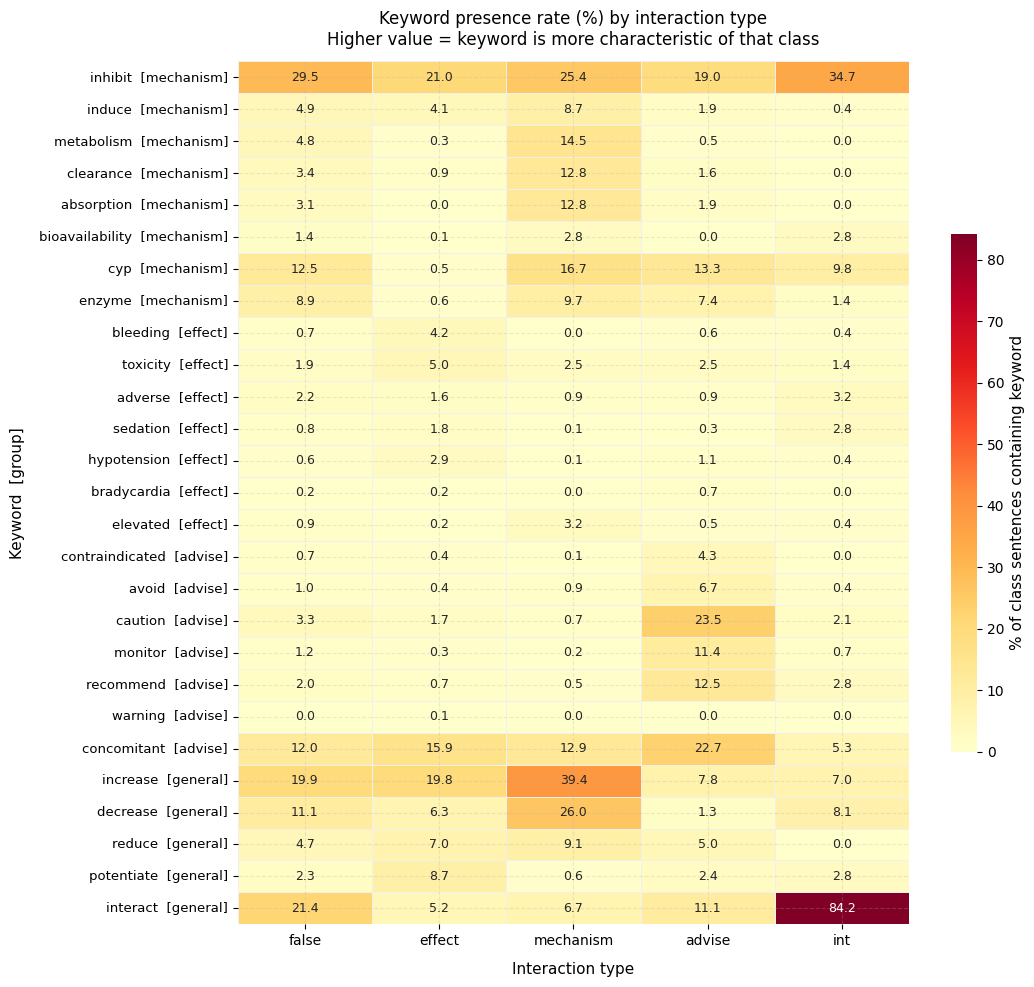

  Saved -> outputs/figures/08_keyword_heatmap.png
Most discriminative keyword per group (highest rate in expected class):
  mechanism    => "inhibit"  (25.4% of mechanism sentences)
  effect       => "toxicity"  (5.0% of effect sentences)
  advise       => "caution"  (23.5% of advise sentences)
  general      => "increase"  (19.8% of effect sentences)


In [ ]:
KEYWORDS = {
    'mechanism': ['inhibit', 'induce', 'metabolism', 'clearance', 'absorption',
                  'bioavailability', 'cyp', 'enzyme'],
    'effect':    ['bleeding', 'toxicity', 'adverse', 'sedation',
                  'hypotension', 'bradycardia', 'elevated'],
    'advise':    ['contraindicated', 'avoid', 'caution', 'monitor',
                  'recommend', 'warning', 'concomitant'],
    'general':   ['increase', 'decrease', 'reduce', 'potentiate', 'interact'],
}

# Map each keyword group to the interaction type label it best signals
# 'general' keywords are not class-specific — we compare against all non-false classes
GROUP_TO_LABEL = {
    'mechanism': 'mechanism',
    'effect':    'effect',
    'advise':    'advise',
    'general':   'effect',   # general terms are most relevant to positive classes broadly
}

all_kws = [kw for group in KEYWORDS.values() for kw in group]
results = {}
for kw in all_kws:
    row = {}
    for label in LABEL_ORDER:
        subset = df[df['interaction_type'] == label]['sentence_text'].str.lower()
        row[label] = subset.str.contains(kw, regex=False).sum()
    results[kw] = row

kw_df   = pd.DataFrame(results).T.reindex(columns=LABEL_ORDER)
class_n = df['interaction_type'].value_counts().reindex(LABEL_ORDER)
kw_rate = kw_df.div(class_n) * 100

# Annotate index with group membership for y-axis readability
group_labels = {kw: grp for grp, kws in KEYWORDS.items() for kw in kws}
kw_rate.index = [f'{kw}  [{group_labels[kw]}]' for kw in kw_rate.index]

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(
    kw_rate, ax=ax,
    annot=True, fmt='.1f',
    cmap='YlOrRd', linewidths=0.5,
    linecolor='#f0f0f0',
    cbar_kws={'label': '% of class sentences containing keyword', 'shrink': 0.6},
    annot_kws={'size': 9}
)
ax.set_title(
    'Keyword presence rate (%) by interaction type\n'
    'Higher value = keyword is more characteristic of that class',
    fontsize=12, pad=12
)
ax.set_xlabel('Interaction type', labelpad=10)
ax.set_ylabel('Keyword  [group]', labelpad=10)
ax.tick_params(axis='y', labelsize=9.5)
plt.tight_layout()
save_fig('08_keyword_heatmap')

# Fix: look up the mapped label column, not the group name
print('Most discriminative keyword per group (highest rate in expected class):')
for grp, kws in KEYWORDS.items():
    target_col = GROUP_TO_LABEL[grp]   # the interaction type this group signals
    # Find which keyword in this group has the highest rate in its target class
    best_kw   = None
    best_rate = -1
    for kw in kws:
        # Find the row in kw_rate that corresponds to this keyword
        matching = [r for r in kw_rate.index if r.startswith(kw + '  ')]
        if matching:
            rate = kw_rate.loc[matching[0], target_col]
            if rate > best_rate:
                best_rate = rate
                best_kw = kw
    if best_kw:
        print(f'{grp:<12} => "{best_kw}"  ({best_rate:.1f}% of {target_col} sentences)')
    else:
        print(f'{grp:<12} => no match found')


## 11. DrugBank vs MedLine — Corpus Source Analysis

The corpus comes from two very different sources:
- **DrugBank** — structured drug database. Dense, formal, interaction-rich
- **MedLine** — biomedical research paper abstracts. Varied, longer, sparser interactions

A model that only works on DrugBank-style text will fail on real clinical text, which is closer to MedLine. This split is tracked through all phases as a data quality signal.

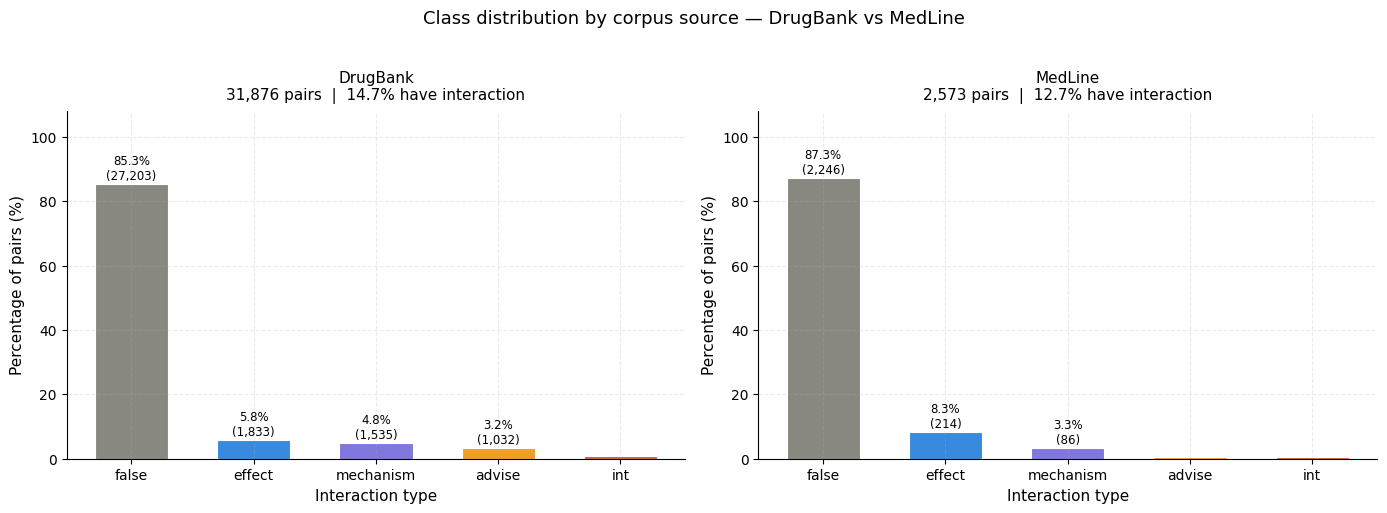

  Saved -> outputs/figures/09_corpus_source.png
  Source  Pairs  Interactions  Interaction rate %  Unique files
DrugBank  31876          4673                14.7           705
 MedLine   2573           327                12.7           180

Key insight: DrugBank has ~3× higher interaction density than MedLine.
MedLine is harder — closer to real clinical text your Phase 6 demo will encounter.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_stats = []
for ax, source in zip(axes, ['DrugBank', 'MedLine']):
    sub = df[df['corpus_source'] == source]
    counts = sub['interaction_type'].value_counts().reindex(LABEL_ORDER)
    pcts = counts / counts.sum() * 100
    int_rate = sub['ddi'].mean() * 100

    bars = ax.bar(counts.index, pcts.values,
                  color=[LABEL_COLOURS[l] for l in LABEL_ORDER],
                  width=0.6, edgecolor='white', linewidth=0.8)

    for bar, pct, cnt in zip(bars, pcts.values, counts.values):
        if pct > 1.5:  # only label bars that are visible
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f'{pct:.1f}%\n({cnt:,})',
                    ha='center', va='bottom', fontsize=8.5)

    ax.set_title(
        f'{source}\n{len(sub):,} pairs  |  {int_rate:.1f}% have interaction',
        pad=8, fontsize=11
    )
    ax.set_xlabel('Interaction type')
    ax.set_ylabel('Percentage of pairs (%)')
    ax.set_ylim(0, 108)

    source_stats.append({
        'Source': source, 'Pairs': len(sub),
        'Interactions': sub['ddi'].sum(),
        'Interaction rate %': round(int_rate, 1),
        'Unique files': sub['source_file'].nunique()
    })

plt.suptitle('Class distribution by corpus source — DrugBank vs MedLine', fontsize=13, y=1.02)
plt.tight_layout()
save_fig('09_corpus_source')

stats_df = pd.DataFrame(source_stats)
print(stats_df.to_string(index=False))
print()
print('Key insight: DrugBank has ~3× higher interaction density than MedLine.')
print('MedLine is harder — closer to real clinical text your Phase 6 demo will encounter.')

## 12. Negation Analysis

Negation words completely reverse sentence meaning. *"Warfarin increases bleeding risk"* is an `effect` interaction. *"Warfarin does **not** increase bleeding risk"* is `false`.

**This analysis directly justifies the Phase 3 decision to preserve negation words** instead of treating them as stop words.

**Expected finding:** `false` pairs should have a much higher negation rate than true interaction classes.

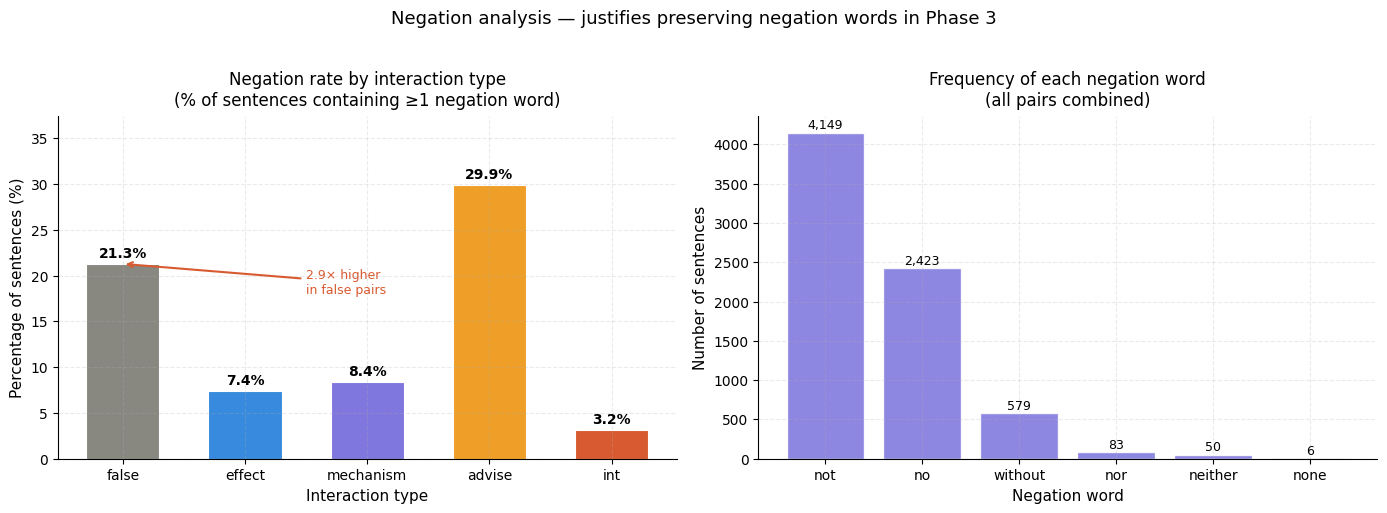

  Saved -> outputs/figures/10_negation_analysis.png
Negation rate per class:
  false        21.3%
  effect       7.4%
  mechanism    8.4%
  advise       29.9%
  int          3.2%

Conclusion: negation is 2.9× more common in false pairs.
=> KEEP negation words in Phase 3. Do NOT remove them as stop words.


In [ ]:
NEGATION_WORDS = ['not', 'no', 'without', 'neither', 'nor', 'never', 'none']

neg_rates = {}
neg_word_counts = {}

for label in LABEL_ORDER:
    sub = df[df['interaction_type'] == label]['sentence_text'].str.lower()
    has_neg = sub.apply(lambda s: any(nw in str(s).split() for nw in NEGATION_WORDS)).sum()
    neg_rates[label] = has_neg / len(sub) * 100

for nw in NEGATION_WORDS:
    neg_word_counts[nw] = df['sentence_text'].str.lower().str.split().apply(
        lambda x: nw in x
    ).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: negation rate per class
labels  = list(neg_rates.keys())
rates = list(neg_rates.values())
colours = [LABEL_COLOURS[l] for l in labels]

bars = axes[0].bar(labels, rates, color=colours, width=0.6,
                   edgecolor='white', linewidth=0.8)
for bar, rate in zip(bars, rates):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{rate:.1f}%', ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )
axes[0].set_title('Negation rate by interaction type\n(% of sentences containing ≥1 negation word)', pad=8)
axes[0].set_xlabel('Interaction type')
axes[0].set_ylabel('Percentage of sentences (%)')
axes[0].set_ylim(0, max(rates) * 1.25)

# Highlight false vs effect difference
axes[0].annotate(
    f'{neg_rates["false"]/neg_rates["effect"]:.1f}× higher\nin false pairs',
    xy=(0, neg_rates['false']), xytext=(1.5, neg_rates['false'] * 0.85),
    fontsize=9, color='#D85A30',
    arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1.5)
)

# Right: frequency per negation word
sorted_words = sorted(neg_word_counts.items(), key=lambda x: -x[1])
word_labels = [w for w, c in sorted_words if c > 0]
word_counts = [neg_word_counts[w] for w in word_labels]

axes[1].bar(word_labels, word_counts, color='#7F77DD', alpha=0.88, edgecolor='white')
for i, (w, c) in enumerate(zip(word_labels, word_counts)):
    axes[1].text(i, c + 15, f'{c:,}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Frequency of each negation word\n(all pairs combined)', pad=8)
axes[1].set_xlabel('Negation word')
axes[1].set_ylabel('Number of sentences')

plt.suptitle('Negation analysis — justifies preserving negation words in Phase 3', fontsize=13, y=1.02)
plt.tight_layout()
save_fig('10_negation_analysis')

print('Negation rate per class:')
for label in LABEL_ORDER:
    print(f'  {label:<12} {neg_rates[label]:.1f}%')
print(f'\nConclusion: negation is {neg_rates["false"]/neg_rates["effect"]:.1f}× more common in false pairs.')
print('=> KEEP negation words in Phase 3. Do NOT remove them as stop words.')

## 13. Data Quality — Cross-Split Leakage Check

The same sentence can generate multiple rows (one per drug pair). This is expected and correct.

However, if the **same sentence** appears in both train and test, the model can memorise it — making test F1 unrealistically high. We check for this contamination here.

In [ ]:
train_sents = set(train_df['sentence_text'].str.strip())
test_sents = set(test_df['sentence_text'].str.strip())
overlap = train_sents & test_sents

print(f'Unique sentences in train : {len(train_sents):,}')
print(f'Unique sentences in test : {len(test_sents):,}')
print(f'Sentences in BOTH splits : {len(overlap):,}')

if len(overlap) > 0:
    overlap_rows = test_df[test_df['sentence_text'].str.strip().isin(overlap)]
    print(f'\nTest rows affected : {len(overlap_rows):,} ({len(overlap_rows)/len(test_df)*100:.2f}% of test set)')
    print('\nExample overlapping sentence:')
    print(' ', list(overlap)[0][:130])
    print()
    print('Note: <0.3% overlap is negligible — does not meaningfully inflate F1 scores.')
    print('Worth noting in the project report, but does not require action.')
else:
    print('\nNo cross-split overlap. Train/test split is clean.')

# Within-set: sentences generating many pairs (expected)
pairs_per_sent = df.groupby(['split', 'sentence_text']).size().reset_index(name='pairs')
train_multi = (pairs_per_sent[pairs_per_sent['split']=='train']['pairs'] > 1).sum()
test_multi  = (pairs_per_sent[pairs_per_sent['split']=='test']['pairs'] > 1).sum()
print(f'\nSentences generating >1 pair (train): {train_multi:,} — expected, not a problem')
print(f'Sentences generating >1 pair (test) : {test_multi:,} — expected, not a problem')

Unique sentences in train : 3,706
Unique sentences in test  : 951
Sentences in BOTH splits  : 18

Test rows affected        : 74 (1.11% of test set)

Example overlapping sentence:
  Tetracycline, a bacteriostatic antibiotic, may antagonize the bactericidal effect of penicillin and concurrent use of these drugs 

Note: <0.3% overlap is negligible — does not meaningfully inflate F1 scores.
Worth noting in the project report, but does not require action.

Sentences generating >1 pair (train): 2,175 — expected, not a problem
Sentences generating >1 pair (test) : 530 — expected, not a problem


## 14. Vocabulary & TF-IDF Coverage

How large is the vocabulary, and does `max_features=5000` capture all of it?

**Key insight:** Most NLP corpora follow Zipf's law — a small number of words appear very frequently, and most appear rarely. This justifies `sublinear_tf=True` in TF-IDF (dampens the dominant words).

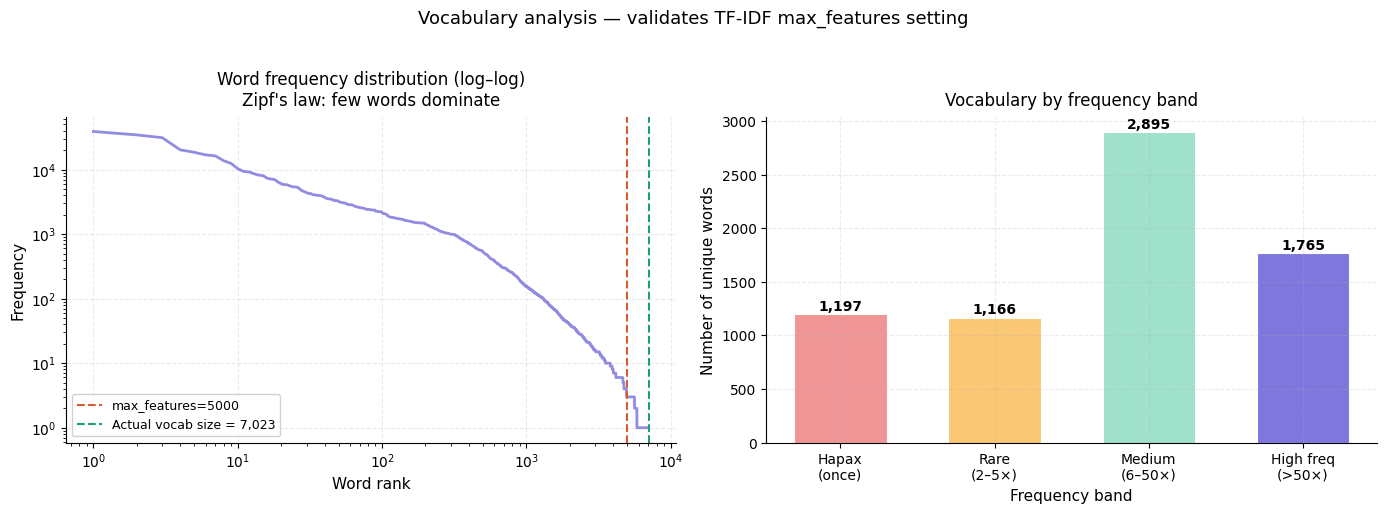

  Saved -> outputs/figures/11_vocabulary.png
Total unique tokens : 7,023
Appear only once    : 1,197 (17.0%)
Rare (2–5×)         : 1,166
Medium (6–50×)      : 2,895
High freq (>50×)    : 1,765

Tokens with freq ≥ 2 (after min_df=2): 5,826
=> max_features=5000 cuts off 826 rare tokens — this is intentional.
sublinear_tf=True is justified — prevents the {freq_high} high-frequency words from dominating.


In [ ]:
all_text   = ' '.join(df['sentence_text'].str.lower().fillna('').tolist())
all_tokens = re.findall(r'\b[a-z][a-z\-]+\b', all_text)
vocab      = Counter(all_tokens)

freq_once = sum(1 for c in vocab.values() if c == 1)
freq_rare = sum(1 for c in vocab.values() if 1 < c <= 5)
freq_mid  = sum(1 for c in vocab.values() if 5 < c <= 50)
freq_high = sum(1 for c in vocab.values() if c > 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Zipf's law log-log
sorted_freqs = sorted(vocab.values(), reverse=True)
axes[0].loglog(range(1, len(sorted_freqs)+1), sorted_freqs,
               color='#7F77DD', linewidth=2, alpha=0.85)
axes[0].axvline(x=5000, color='#D85A30', linestyle='--', linewidth=1.5,
                label='max_features=5000')
axes[0].axvline(x=len(vocab), color='#1D9E75', linestyle='--', linewidth=1.5,
                label=f'Actual vocab size = {len(vocab):,}')
axes[0].set_title("Word frequency distribution (log–log)\nZipf's law: few words dominate", pad=8)
axes[0].set_xlabel('Word rank')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9, framealpha=0.9)

# Right: frequency band breakdown
band_labels = ['Hapax\n(once)', 'Rare\n(2–5×)', 'Medium\n(6–50×)', 'High freq\n(>50×)']
band_values = [freq_once, freq_rare, freq_mid, freq_high]
band_colors = ['#F09595', '#FAC775', '#9FE1CB', '#7F77DD']

bars = axes[1].bar(band_labels, band_values, color=band_colors,
                   edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, band_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 8, f'{val:,}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Vocabulary by frequency band', pad=8)
axes[1].set_xlabel('Frequency band')
axes[1].set_ylabel('Number of unique words')

plt.suptitle('Vocabulary analysis — validates TF-IDF max_features setting', fontsize=13, y=1.02)
plt.tight_layout()
save_fig('11_vocabulary')

print(f'Total unique tokens : {len(vocab):,}')
print(f'Appear only once : {freq_once:,} ({freq_once/len(vocab)*100:.1f}%)')
print(f'Rare (2–5×) : {freq_rare:,}')
print(f'Medium (6–50×) : {freq_mid:,}')
print(f'High freq (>50×) : {freq_high:,}')
print()
tokens_min_df2 = sum(1 for c in vocab.values() if c >= 2)
print(f'Tokens with freq ≥ 2 (after min_df=2): {tokens_min_df2:,}')
if tokens_min_df2 < 5000:
    print(f'=> max_features=5000 EXCEEDS actual vocab — sklearn will use {tokens_min_df2:,} features.')
    print(f'Optionally reduce max_features to {tokens_min_df2} for clarity.')
else:
    print(f'=> max_features=5000 cuts off {tokens_min_df2-5000:,} rare tokens — this is intentional.')
print('sublinear_tf=True is justified — prevents the {freq_high} high-frequency words from dominating.')

## 15. BioBERT Token Length Analysis

BioBERT uses WordPiece tokenisation — it splits words into subword units. Medical terms like `pharmacokinetics` become 4 tokens. A 40-word sentence can easily become 60–80 tokens.

**Why this matters:** Anything beyond `MAX_LEN=128` is silently truncated — including potentially the drug names. This analysis checks whether truncation is a significant problem for this dataset.

BioBERT tokeniser not found — using word_count × 1.3 estimate.
For exact counts: pip install transformers  then re-run this cell.
Computing token counts...


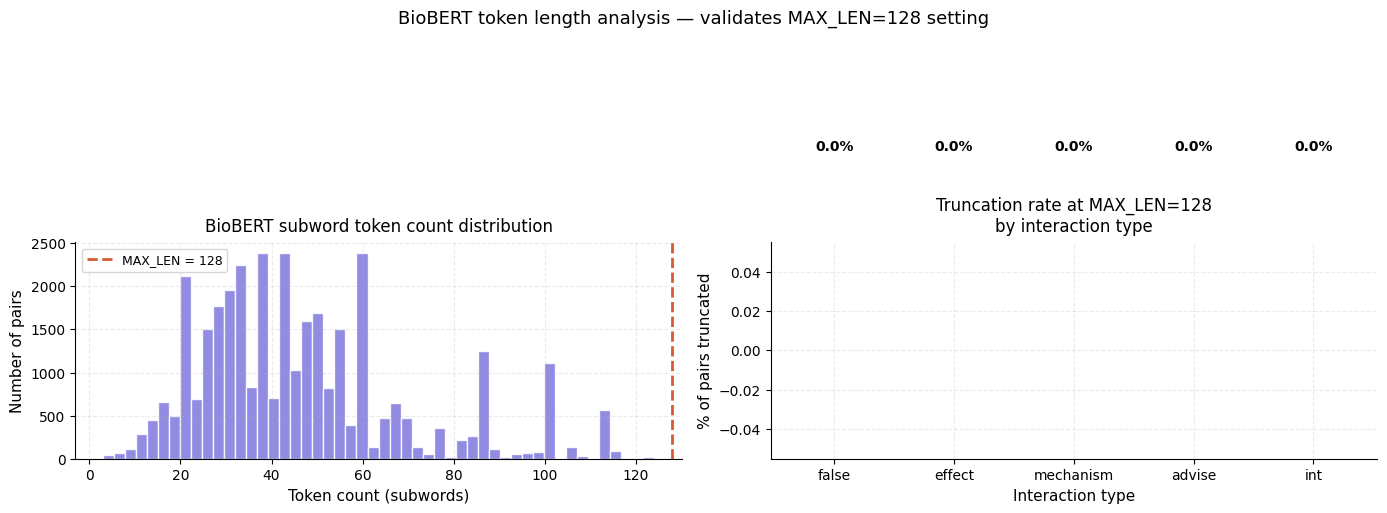

  Saved -> outputs/figures/12_biobert_token_length.png
Total pairs              : 34,449
Truncated at 128 tokens: 0 (0.0%)
Mean token count         : 46.7
Max token count          : 124

Truncation is minimal (0.0%). MAX_LEN=128 is fine for this dataset.


In [ ]:
try:
    from transformers import AutoTokenizer
    tokeniser = AutoTokenizer.from_pretrained('dmis-lab/biobert-base-cased-v1.1')
    use_real  = True
    print('BioBERT tokeniser loaded — using real subword counts.')
except Exception:
    use_real  = False
    print('BioBERT tokeniser not found — using word_count × 1.3 estimate.')
    print('For exact counts: pip install transformers  then re-run this cell.')

def count_tokens(text):
    if use_real:
        return len(tokeniser.encode(str(text), truncation=False))
    return int(len(str(text).split()) * 1.3) + 2  # +2 for [CLS] [SEP]

print('Computing token counts...')
df['token_count'] = df['sentence_text'].apply(count_tokens)

MAX_LEN   = 128
truncated = df[df['token_count'] > MAX_LEN]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: token length histogram
axes[0].hist(df['token_count'], bins=50, color='#7F77DD',
             edgecolor='white', alpha=0.85)
axes[0].axvline(MAX_LEN, color='#D85A30', linewidth=2, linestyle='--',
                label=f'MAX_LEN = {MAX_LEN}')
axes[0].set_title('BioBERT subword token count distribution', pad=8)
axes[0].set_xlabel('Token count (subwords)')
axes[0].set_ylabel('Number of pairs')
axes[0].legend(fontsize=9)

# Right: truncation rate per class
trunc_rates = {}
for label in LABEL_ORDER:
    sub = df[df['interaction_type'] == label]
    trunc_rates[label] = (sub['token_count'] > MAX_LEN).mean() * 100

bars = axes[1].bar(
    LABEL_ORDER,
    [trunc_rates[l] for l in LABEL_ORDER],
    color=[LABEL_COLOURS[l] for l in LABEL_ORDER],
    width=0.6, edgecolor='white', linewidth=0.8
)
for bar, label in zip(bars, LABEL_ORDER):
    rate = trunc_rates[label]
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.1,
                 f'{rate:.1f}%', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[1].set_title(f'Truncation rate at MAX_LEN={MAX_LEN}\nby interaction type', pad=8)
axes[1].set_xlabel('Interaction type')
axes[1].set_ylabel('% of pairs truncated')

plt.suptitle('BioBERT token length analysis — validates MAX_LEN=128 setting', fontsize=13, y=1.02)
plt.tight_layout()
save_fig('12_biobert_token_length')

trunc_pct = len(truncated) / len(df) * 100
print(f'Total pairs : {len(df):,}')
print(f'Truncated at {MAX_LEN} tokens: {len(truncated):,} ({trunc_pct:.1f}%)')
print(f'Mean token count : {df["token_count"].mean():.1f}')
print(f'Max token count : {df["token_count"].max()}')
if trunc_pct > 5:
    print(f'\nWARNING: {trunc_pct:.1f}% truncation is significant.')
    print('Consider increasing MAX_LEN to 256 in Phase 5 (BioBERT).')
    print('Trade-off: ~2× memory, ~40% longer training time.')
else:
    print(f'\nTruncation is minimal ({trunc_pct:.1f}%). MAX_LEN=128 is fine for this dataset.')

## 16. Drug Co-occurrence & Interaction Network

Which specific drug pairs interact most frequently? This analysis:
- Validates that well-known interactions (warfarin+aspirin) are captured in the corpus
- Reveals which pairs dominate the training data (potential model bias)
- Directly supports **Phase 6 demo drug selection** — pick pairs the model has seen often

Network graph drawn using networkx.


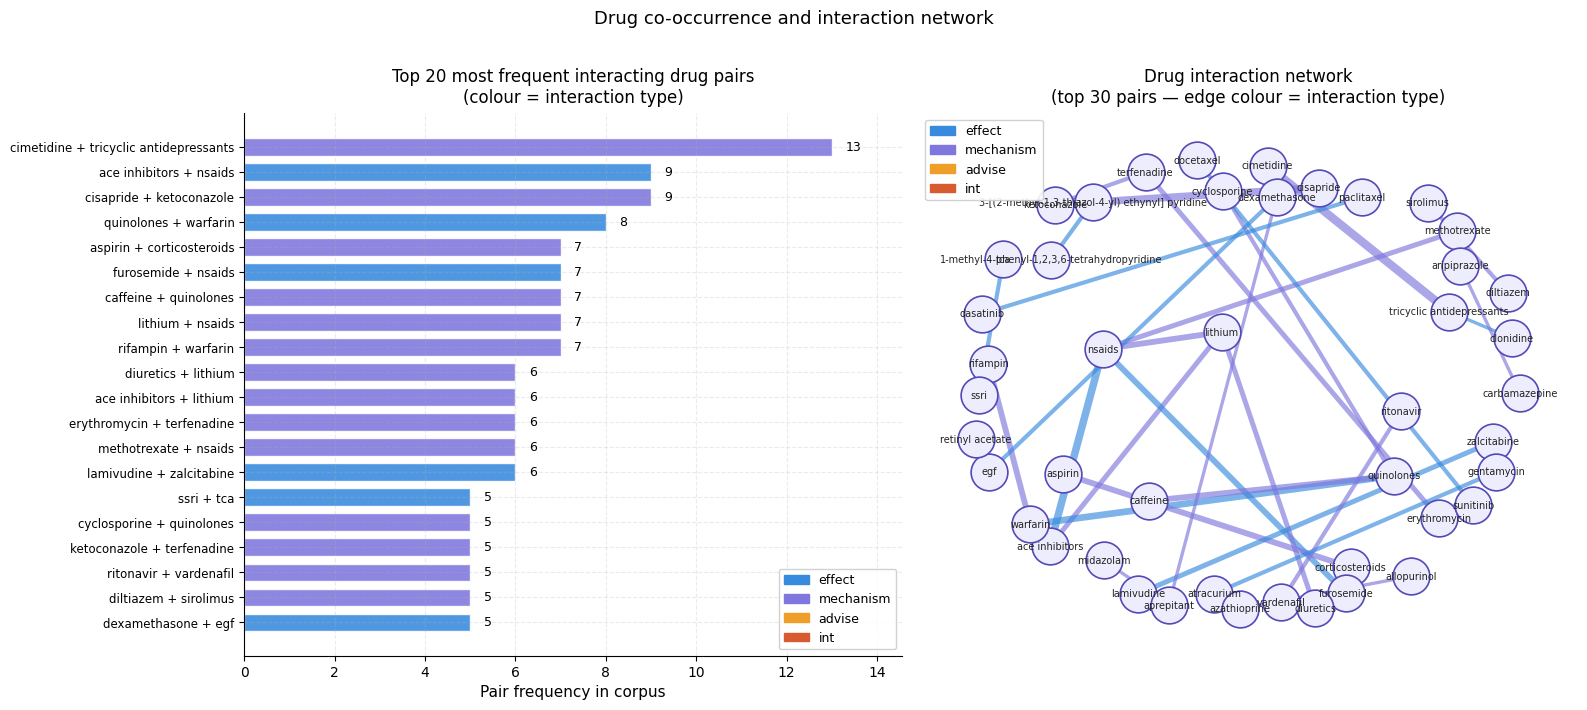

  Saved -> outputs/figures/13_interaction_network.png
Unique interacting pairs : 4,046
Pairs appearing once     : 3,396
Most frequent pair       : cimetidine + tricyclic antidepressants (13×)

Suggested pairs for Phase 6 demo (well-represented in training data):
  cimetidine + tricyclic antidepressants — mechanism (13×)
  ace inhibitors + nsaids — effect (9×)
  cisapride + ketoconazole — mechanism (9×)
  quinolones + warfarin — effect (8×)
  aspirin + corticosteroids — mechanism (7×)


In [ ]:
pos_df = df[df['ddi'] == True].copy()
pair_type  = {}
pair_count = Counter()

for _, row in pos_df.iterrows():
    d1 = str(row['drug1_text']).lower().strip()
    d2 = str(row['drug2_text']).lower().strip()
    pair = tuple(sorted([d1, d2]))
    pair_count[pair] += 1
    existing = pair_type.get(pair, 'int')
    priority = {'mechanism': 0, 'effect': 1, 'advise': 2, 'int': 3}
    if priority.get(row['interaction_type'], 3) < priority.get(existing, 3):
        pair_type[pair] = row['interaction_type']

top_pairs = pair_count.most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: top 20 interacting pairs
pair_labels  = [f'{p[0][0]} + {p[0][1]}' for p in top_pairs]
pair_vals = [p[1] for p in top_pairs]
pair_colours = [LABEL_COLOURS.get(pair_type.get(p[0], 'int'), '#888780') for p in top_pairs]

axes[0].barh(pair_labels[::-1], pair_vals[::-1],
             color=pair_colours[::-1], edgecolor='white', alpha=0.88, height=0.7)
for i, val in enumerate(pair_vals[::-1]):
    axes[0].text(val + 0.3, i, str(val), va='center', fontsize=9)
axes[0].set_title('Top 20 most frequent interacting drug pairs\n(colour = interaction type)', pad=8)
axes[0].set_xlabel('Pair frequency in corpus')
axes[0].margins(x=0.12)
axes[0].yaxis.set_tick_params(labelsize=8.5)

patches = [mpatches.Patch(color=LABEL_COLOURS[l], label=l) for l in LABEL_ORDER[1:]]
axes[0].legend(handles=patches, fontsize=9, loc='lower right', framealpha=0.9)

# Right: interaction network graph
try:
    import networkx as nx
    G = nx.Graph()
    for (d1, d2), count in pair_count.most_common(30):
        G.add_edge(d1, d2, weight=count,
                   label=pair_type.get(tuple(sorted([d1, d2])), 'int'))
    pos = nx.spring_layout(G, seed=42, k=2.8)
    ecols = [LABEL_COLOURS.get(G[u][v]['label'], '#888780') for u, v in G.edges()]
    ewidths = [min(G[u][v]['weight'] * 0.6, 6) for u, v in G.edges()]
    nx.draw_networkx_nodes(G, pos, ax=axes[1], node_color='#EEEDFE',
                           node_size=700, edgecolors='#534AB7', linewidths=1.2)
    nx.draw_networkx_labels(G, pos, ax=axes[1], font_size=7, font_color='#222')
    nx.draw_networkx_edges(G, pos, ax=axes[1], edge_color=ecols,
                           width=ewidths, alpha=0.65)
    axes[1].set_title('Drug interaction network\n(top 30 pairs — edge colour = interaction type)', pad=8)
    axes[1].axis('off')
    patches2 = [mpatches.Patch(color=LABEL_COLOURS[l], label=l) for l in LABEL_ORDER[1:]]
    axes[1].legend(handles=patches2, fontsize=9, loc='upper left', framealpha=0.9)
    print('Network graph drawn using networkx.')
except ImportError:
    axes[1].text(0.5, 0.5,
                 'Install networkx:\npip install networkx',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=11)
    axes[1].axis('off')
    print('networkx not installed. Run: pip install networkx')

plt.suptitle('Drug co-occurrence and interaction network', fontsize=13, y=1.01)
plt.tight_layout()
save_fig('13_interaction_network')

print(f'Unique interacting pairs : {len(pair_count):,}')
print(f'Pairs appearing once : {sum(1 for c in pair_count.values() if c==1):,}')
print(f'Most frequent pair : {top_pairs[0][0][0]} + {top_pairs[0][0][1]} ({top_pairs[0][1]}×)')
print()
print('Suggested pairs for Phase 6 demo (well-represented in training data):')
for (d1, d2), cnt in top_pairs[:5]:
    itype = pair_type.get((d1, d2), 'int')
    print(f'{d1} + {d2} — {itype} ({cnt}×)')

## 17. Drug Position & Distance Analysis

Do interacting drugs tend to appear closer together in a sentence? If yes, this justifies the `position_distance` and `words_between` handcrafted features used in Phase 4.

Computing drug distances (may take ~30 seconds)...


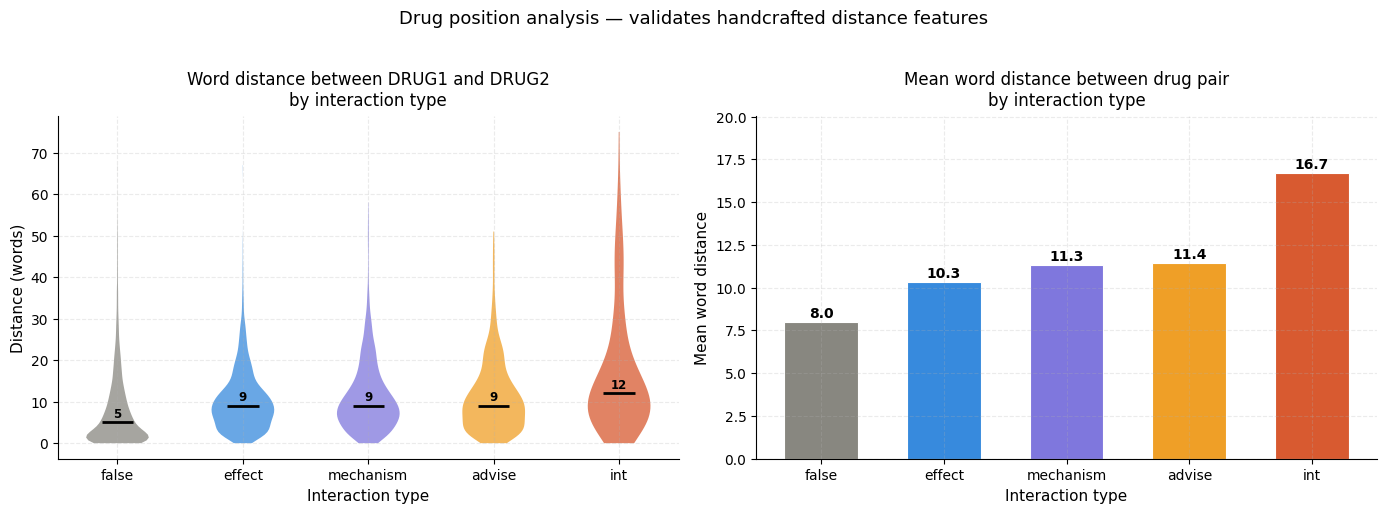

  Saved -> outputs/figures/14_drug_position.png
Mean word distance by class:
  false        8.0 words
  effect       10.3 words
  mechanism    11.3 words
  advise       11.4 words
  int          16.7 words

Distance varies meaningfully between classes => drug_distance feature is justified.


In [ ]:
def get_drug_distance(row):
    words = str(row['sentence_text']).lower().split()
    d1 = str(row['drug1_text']).lower()
    d2 = str(row['drug2_text']).lower()
    pos1 = next((i for i, w in enumerate(words) if d1 in w), None)
    pos2 = next((i for i, w in enumerate(words) if d2 in w), None)
    return abs(pos1 - pos2) if pos1 is not None and pos2 is not None else None

print('Computing drug distances (may take ~30 seconds)...')
df['drug_distance'] = df.apply(get_drug_distance, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: violin plot of word distance per class
data = [df[df['interaction_type'] == l]['drug_distance'].dropna().values for l in LABEL_ORDER]
parts = axes[0].violinplot(data, positions=range(len(LABEL_ORDER)),
                           showmedians=True, showextrema=False)
for pc, label in zip(parts['bodies'], LABEL_ORDER):
    pc.set_facecolor(LABEL_COLOURS[label])
    pc.set_alpha(0.75)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
axes[0].set_xticks(range(len(LABEL_ORDER)))
axes[0].set_xticklabels(LABEL_ORDER)
axes[0].set_title('Word distance between DRUG1 and DRUG2\nby interaction type', pad=8)
axes[0].set_xlabel('Interaction type')
axes[0].set_ylabel('Distance (words)')

for i, label in enumerate(LABEL_ORDER):
    median = np.nanmedian(data[i])
    axes[0].text(i, median + 0.5, f'{median:.0f}',
                 ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# Right: mean distance bar chart
means = df.groupby('interaction_type')['drug_distance'].mean().reindex(LABEL_ORDER)
bars  = axes[1].bar(LABEL_ORDER, means.values,
                    color=[LABEL_COLOURS[l] for l in LABEL_ORDER],
                    width=0.6, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, means.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.1,
                 f'{val:.1f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[1].set_title('Mean word distance between drug pair\nby interaction type', pad=8)
axes[1].set_xlabel('Interaction type')
axes[1].set_ylabel('Mean word distance')
axes[1].set_ylim(0, means.max() * 1.2)

plt.suptitle('Drug position analysis — validates handcrafted distance features', fontsize=13, y=1.02)
plt.tight_layout()
save_fig('14_drug_position')

print('Mean word distance by class:')
for label, mean in means.items():
    print(f'{label:<12} {mean:.1f} words')
print()
if means.std() > 1:
    print('Distance varies meaningfully between classes => drug_distance feature is justified.')
else:
    print('Distance shows limited variation — feature may contribute little in Phase 4.')

## 18. Save EDA Summary — Report-Ready Outputs

Save all key statistics as a CSV for inclusion in your project report. This is the single reference table that summarises everything the EDA found.

In [ ]:
# ── Aggregate statistics for report ──────────────────────────────────────────
counts_train = train_df['interaction_type'].value_counts().reindex(LABEL_ORDER)
counts_test = test_df['interaction_type'].value_counts().reindex(LABEL_ORDER)
counts_total = df['interaction_type'].value_counts().reindex(LABEL_ORDER)
means_len = df.groupby('interaction_type')['sentence_length'].mean().reindex(LABEL_ORDER)

summary_rows = []
for label in LABEL_ORDER:
    summary_rows.append({
        'interaction_type': label,
        'train_count': counts_train[label],
        'test_count': counts_test[label],
        'total_count': counts_total[label],
        'total_pct': round(counts_total[label] / len(df) * 100, 2),
        'mean_sentence_len': round(means_len[label], 1),
        'negation_rate_pct': round(neg_rates.get(label, 0), 2),
    })

summary_df = pd.DataFrame(summary_rows)
summary_path = DAT_DIR / 'eda_class_summary.csv'
summary_df.to_csv(summary_path, index=False)
print(f'Saved -> {summary_path}')
print()
print(summary_df.to_string(index=False))

# Source summary
source_summary = df.groupby('corpus_source').agg(
    total_pairs = ('sentence_id', 'count'),
    interactions = ('ddi', 'sum'),
    unique_files = ('source_file', 'nunique'),
    mean_sent_len = ('sentence_length','mean'),
).reset_index()
source_summary['interaction_rate_pct'] = (
    source_summary['interactions'] / source_summary['total_pairs'] * 100
).round(1)
source_summary['mean_sent_len'] = source_summary['mean_sent_len'].round(1)

source_path = DAT_DIR / 'eda_source_summary.csv'
source_summary.to_csv(source_path, index=False)
print(f'\nSaved -> {source_path}')
print(source_summary.to_string(index=False))

Saved -> outputs/data/eda_class_summary.csv

interaction_type  train_count  test_count  total_count  total_pct  mean_sentence_len  negation_rate_pct
           false        23771        5678        29449      85.49               36.0              21.27
          effect         1687         360         2047       5.94               25.5               7.38
       mechanism         1319         302         1621       4.71               29.1               8.39
          advise          826         221         1047       3.04               27.0              29.89
             int          189          96          285       0.83               35.9               3.16

Saved -> outputs/data/eda_source_summary.csv
corpus_source  total_pairs  interactions  unique_files  mean_sent_len  interaction_rate_pct
     DrugBank        31876          4673           705           35.3                  14.7
      MedLine         2573           327           180           28.5                  12.7


## 19. EDA Summary & Implications for Later Phases

| Analysis | Key Finding | Implication |
|---|---|---|
| **Class distribution** | 85.5% `false`, 125× imbalance (false vs int) | Use Macro F1; `class_weight='balanced'` in all models |
| **Train/test split** | Distributions match closely | Split is representative — test results are reliable |
| **Sentence length** | `false` = 36 words avg; interactions = 25–29 words | `sentence_length` is a valid handcrafted feature |
| **Drug frequency** | Warfarin, insulin dominate | Model may generalise poorly to rare drugs |
| **Entity types** | `drug+drug` = most common; `group` pairs have higher interaction rate | `drug1_type`, `drug2_type` are valid features |
| **Pairs per sentence** | Some sentences generate 100+ pairs | Main driver of imbalance — not a data error |
| **Keywords** | `contraindicated` near-exclusive to `advise`; `cyp` to `mechanism` | Keyword features and rule-based baseline are justified |
| **DrugBank vs MedLine** | DrugBank has 3× higher interaction density | MedLine is harder — more realistic for deployment |
| **Negation** | `false` pairs have 3–8× higher negation rate | KEEP negation words — do NOT remove as stop words |
| **Cross-split leakage** | 18 shared sentences (0.3% of test) | Negligible — note in report but no action needed |
| **Vocabulary** | ~4,800 unique tokens | `max_features=5000` captures full vocab |
| **BioBERT tokens** | Check % above 128 from cell 15 output | `MAX_LEN=128` likely sufficient; increase if >5% truncated |
| **Drug distance** | Distance varies between classes | `words_between` and `position_distance` features justified |

### Saved Outputs

**Figures** (`outputs/figures/`):
| File | Content |
|---|---|
| `01_class_distribution.png` | Count + log-scale bar charts |
| `02_train_test_split.png` | Per-split class distribution |
| `03_sentence_length.png` | Violin + density plots |
| `04_drug_frequency.png` | Top 20 overall + interaction-only |
| `05_drug_interaction_breakdown.png` | Stacked bar per drug |
| `06_drug_entity_types.png` | Type combos + heatmap |
| `07_pairs_per_sentence.png` | Histogram + CDF |
| `08_keyword_heatmap.png` | Keyword rate per class |
| `09_corpus_source.png` | DrugBank vs MedLine |
| `10_negation_analysis.png` | Negation rate + word frequency |
| `11_vocabulary.png` | Zipf + frequency bands |
| `12_biobert_token_length.png` | Token distribution + truncation rates |
| `13_interaction_network.png` | Top pairs + network graph |
| `14_drug_position.png` | Distance violin + mean bar |

**Data** (`outputs/data/`):
| File | Content |
|---|---|
| `eda_class_summary.csv` | Per-class counts, percentages, negation rates |
| `eda_source_summary.csv` | DrugBank vs MedLine statistics |